# dataset description
## Presidential election data (2nd round, 2026)
**source**: registraduria nacional del estado civil

**dataset**: [resultados elecciones presidenciales 2026](https://resultados.registraduria.gov.co/v2/resultados/0/00)

# code
## imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text

pd.set_option("display.float_format", lambda x: "%.2f" % x)

## Load data

In [2]:
path = "./data/elecciones_2026.csv"

df = pd.read_csv(path, encoding="utf-8")
df_1st = pd.read_csv("./data/elecciones_2026_1st.csv", encoding="utf-8")

## Clean data

In [3]:
def get_largest_growth(df_2nd: pd.DataFrame, df_1st: pd.DataFrame, candidate: str) -> pd.DataFrame:
    def dept_votes(df: pd.DataFrame) -> pd.Series:
        return df[
            (~df["Ambito"].eq("NACIONAL")) &
            (df["Concepto"].eq(candidate))
        ].set_index("Ambito")["Votos"]

    net = (dept_votes(df_2nd) - dept_votes(df_1st)).nlargest(5).sort_values(ascending=True)

    return net

cepeda_growth = get_largest_growth(df, df_1st, "IVÁN CEPEDA CASTRO")
abelardo_growth = get_largest_growth(df, df_1st, "ABELARDO DE LA ESPRIELLA")

## Plot

In [4]:
def plot_departments(df: pd.DataFrame, candidate: str, color: str, subtitle_phrase: str = "Departments with more votes"):
    plt.figure(figsize=(10.8, 10), dpi=500)

    plt.barh(df.index, df.values, color=color)

    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}K"))

    for side in ["top", "bottom", "left", "right"]:
        plt.gca().spines[side].set_visible(False)

    plt.tick_params(axis="x", length=0)

    fig_text(
    x=0.125, y=0.95,
    s=f"<{candidate}> - {subtitle_phrase}",
    highlight_textprops=[{"color": color, "weight": "bold"}],
    fontsize=15,
    )

    fig_text(
        x=0.125, y=0.915,
        s="Presidential election, 2nd round · 2026 · 99.94% of the tables counted",
        fontsize=10, color="gray",
    )

    fig_text(
        0.125, 0.01, 
        "Source: Registraduría Nacional del Estado Civil\n"
        "By Andrés Ríos for Statictics on Colombia.", 
        fontsize=8, color="gray",
    )

    plt.show()

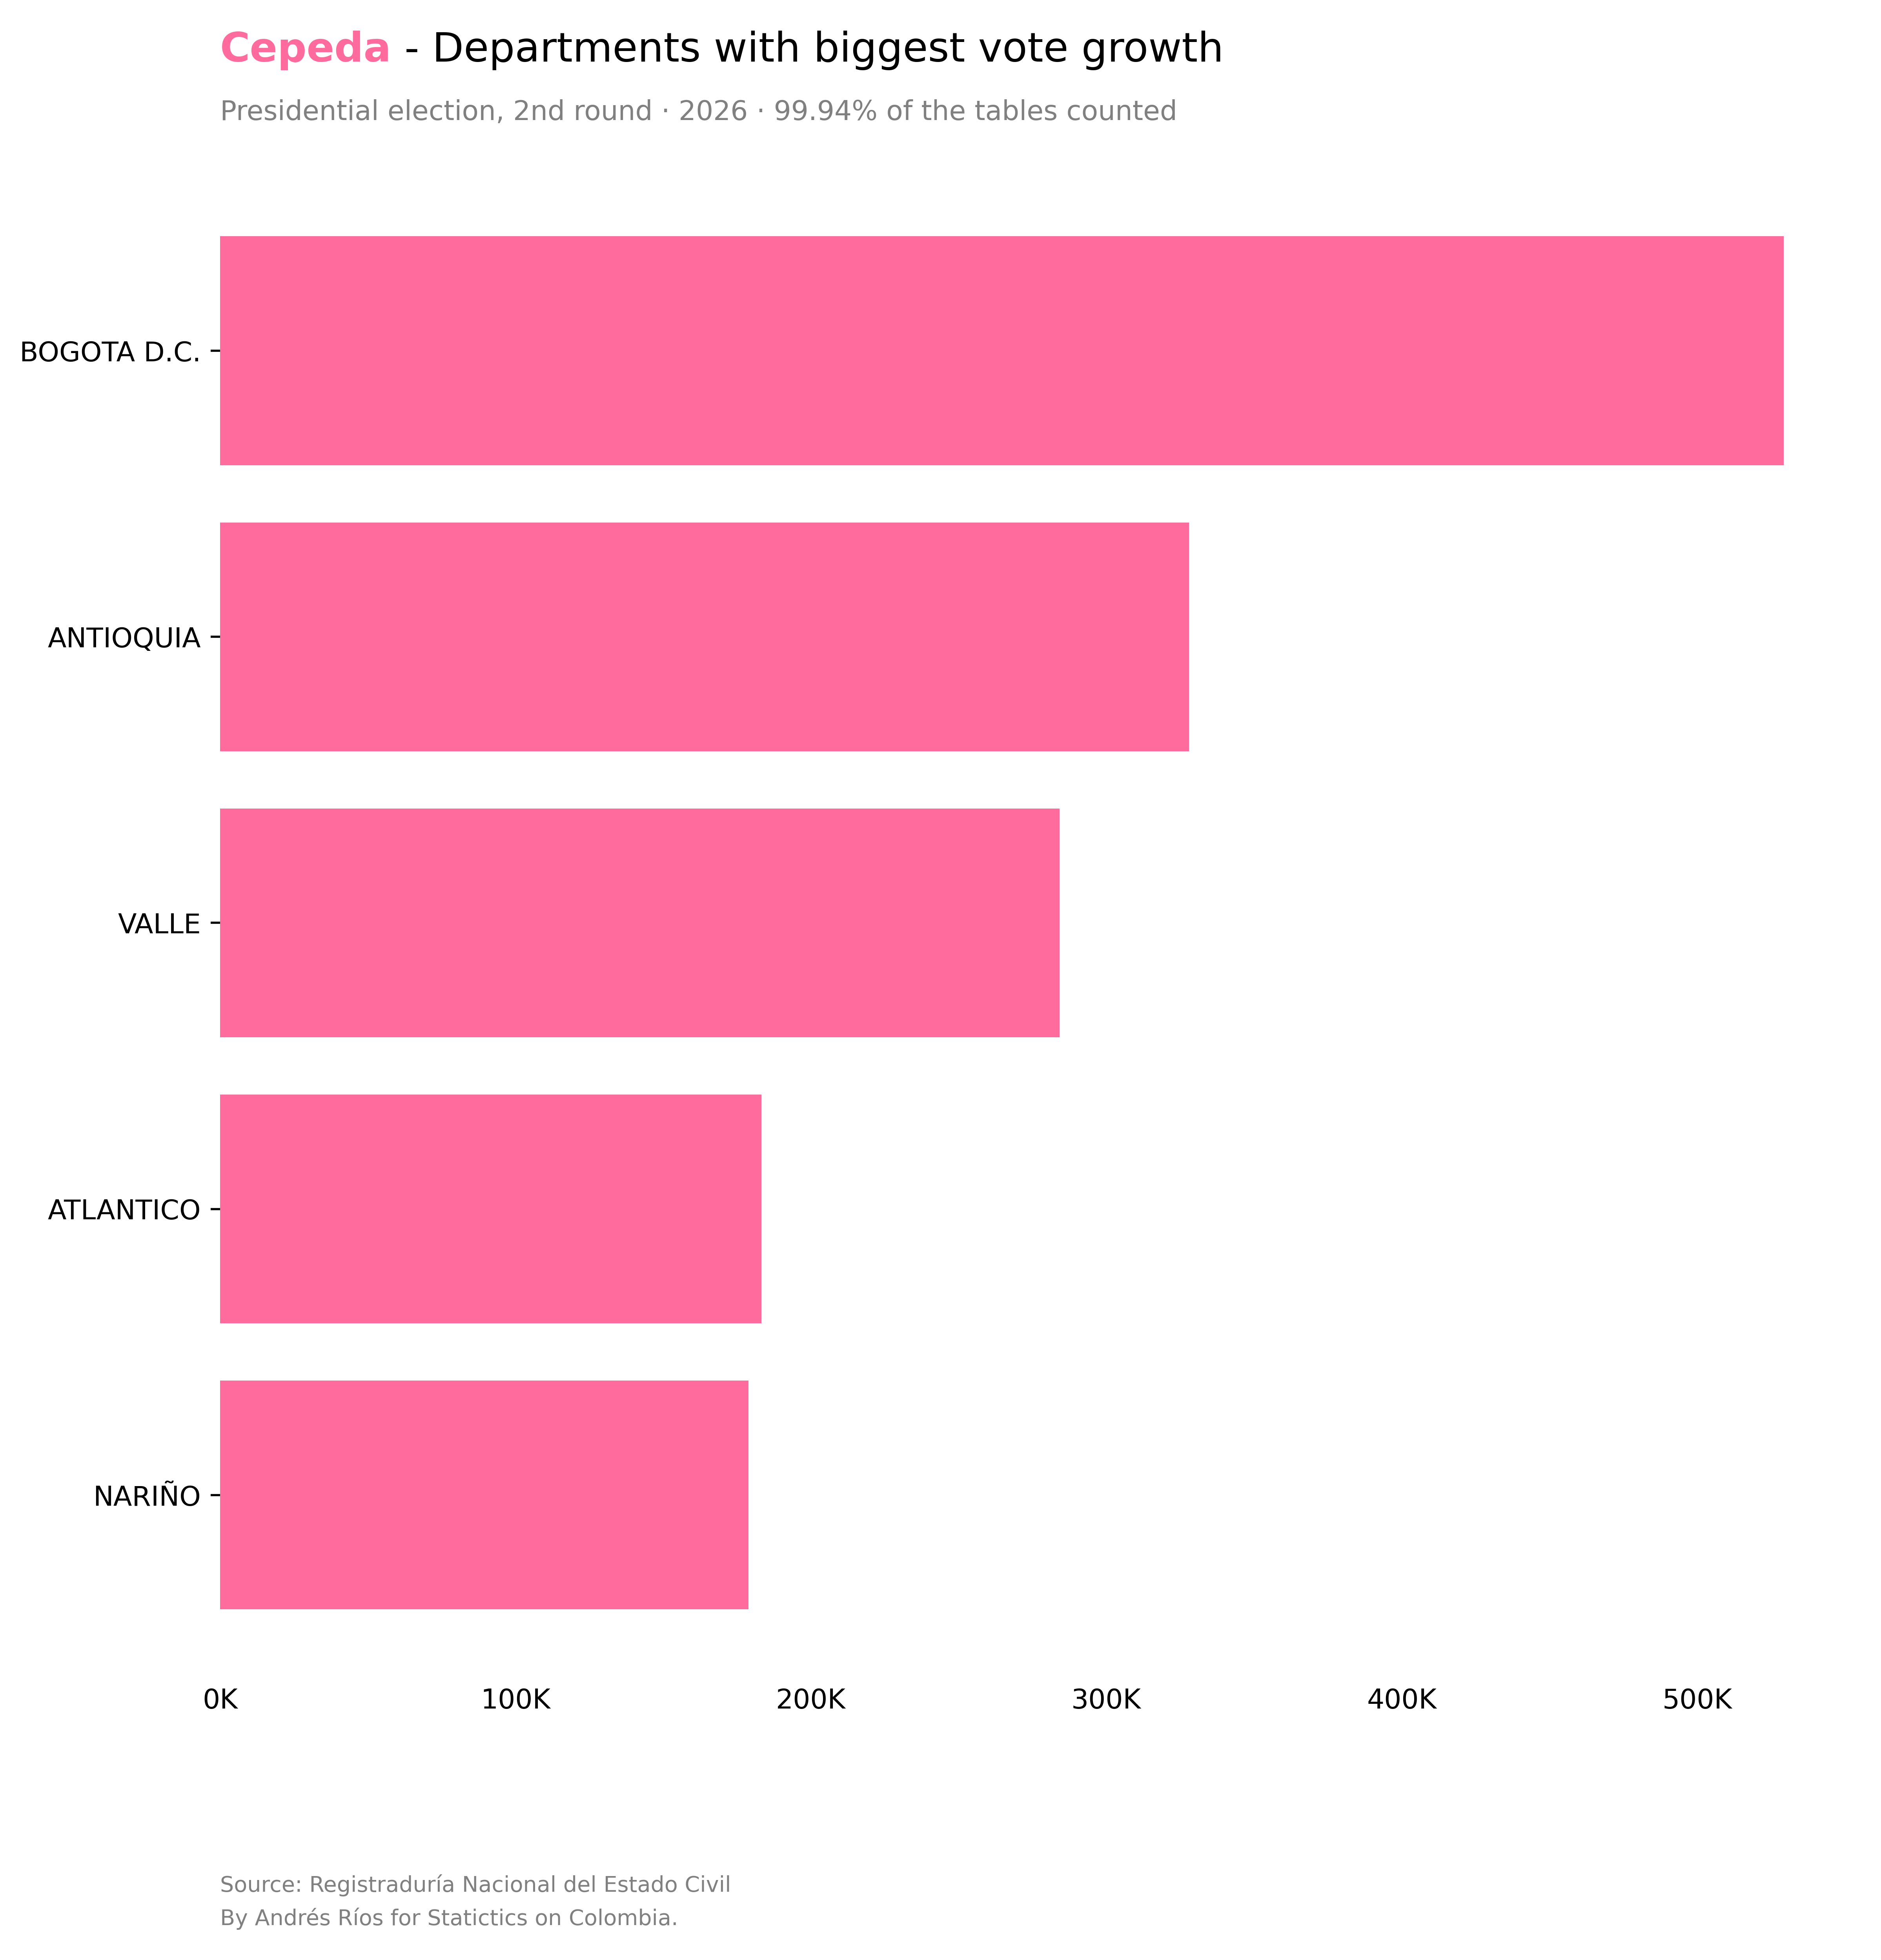

In [5]:
plot_departments(cepeda_growth, "Cepeda", "#FF6B9D", "Departments with biggest vote growth")

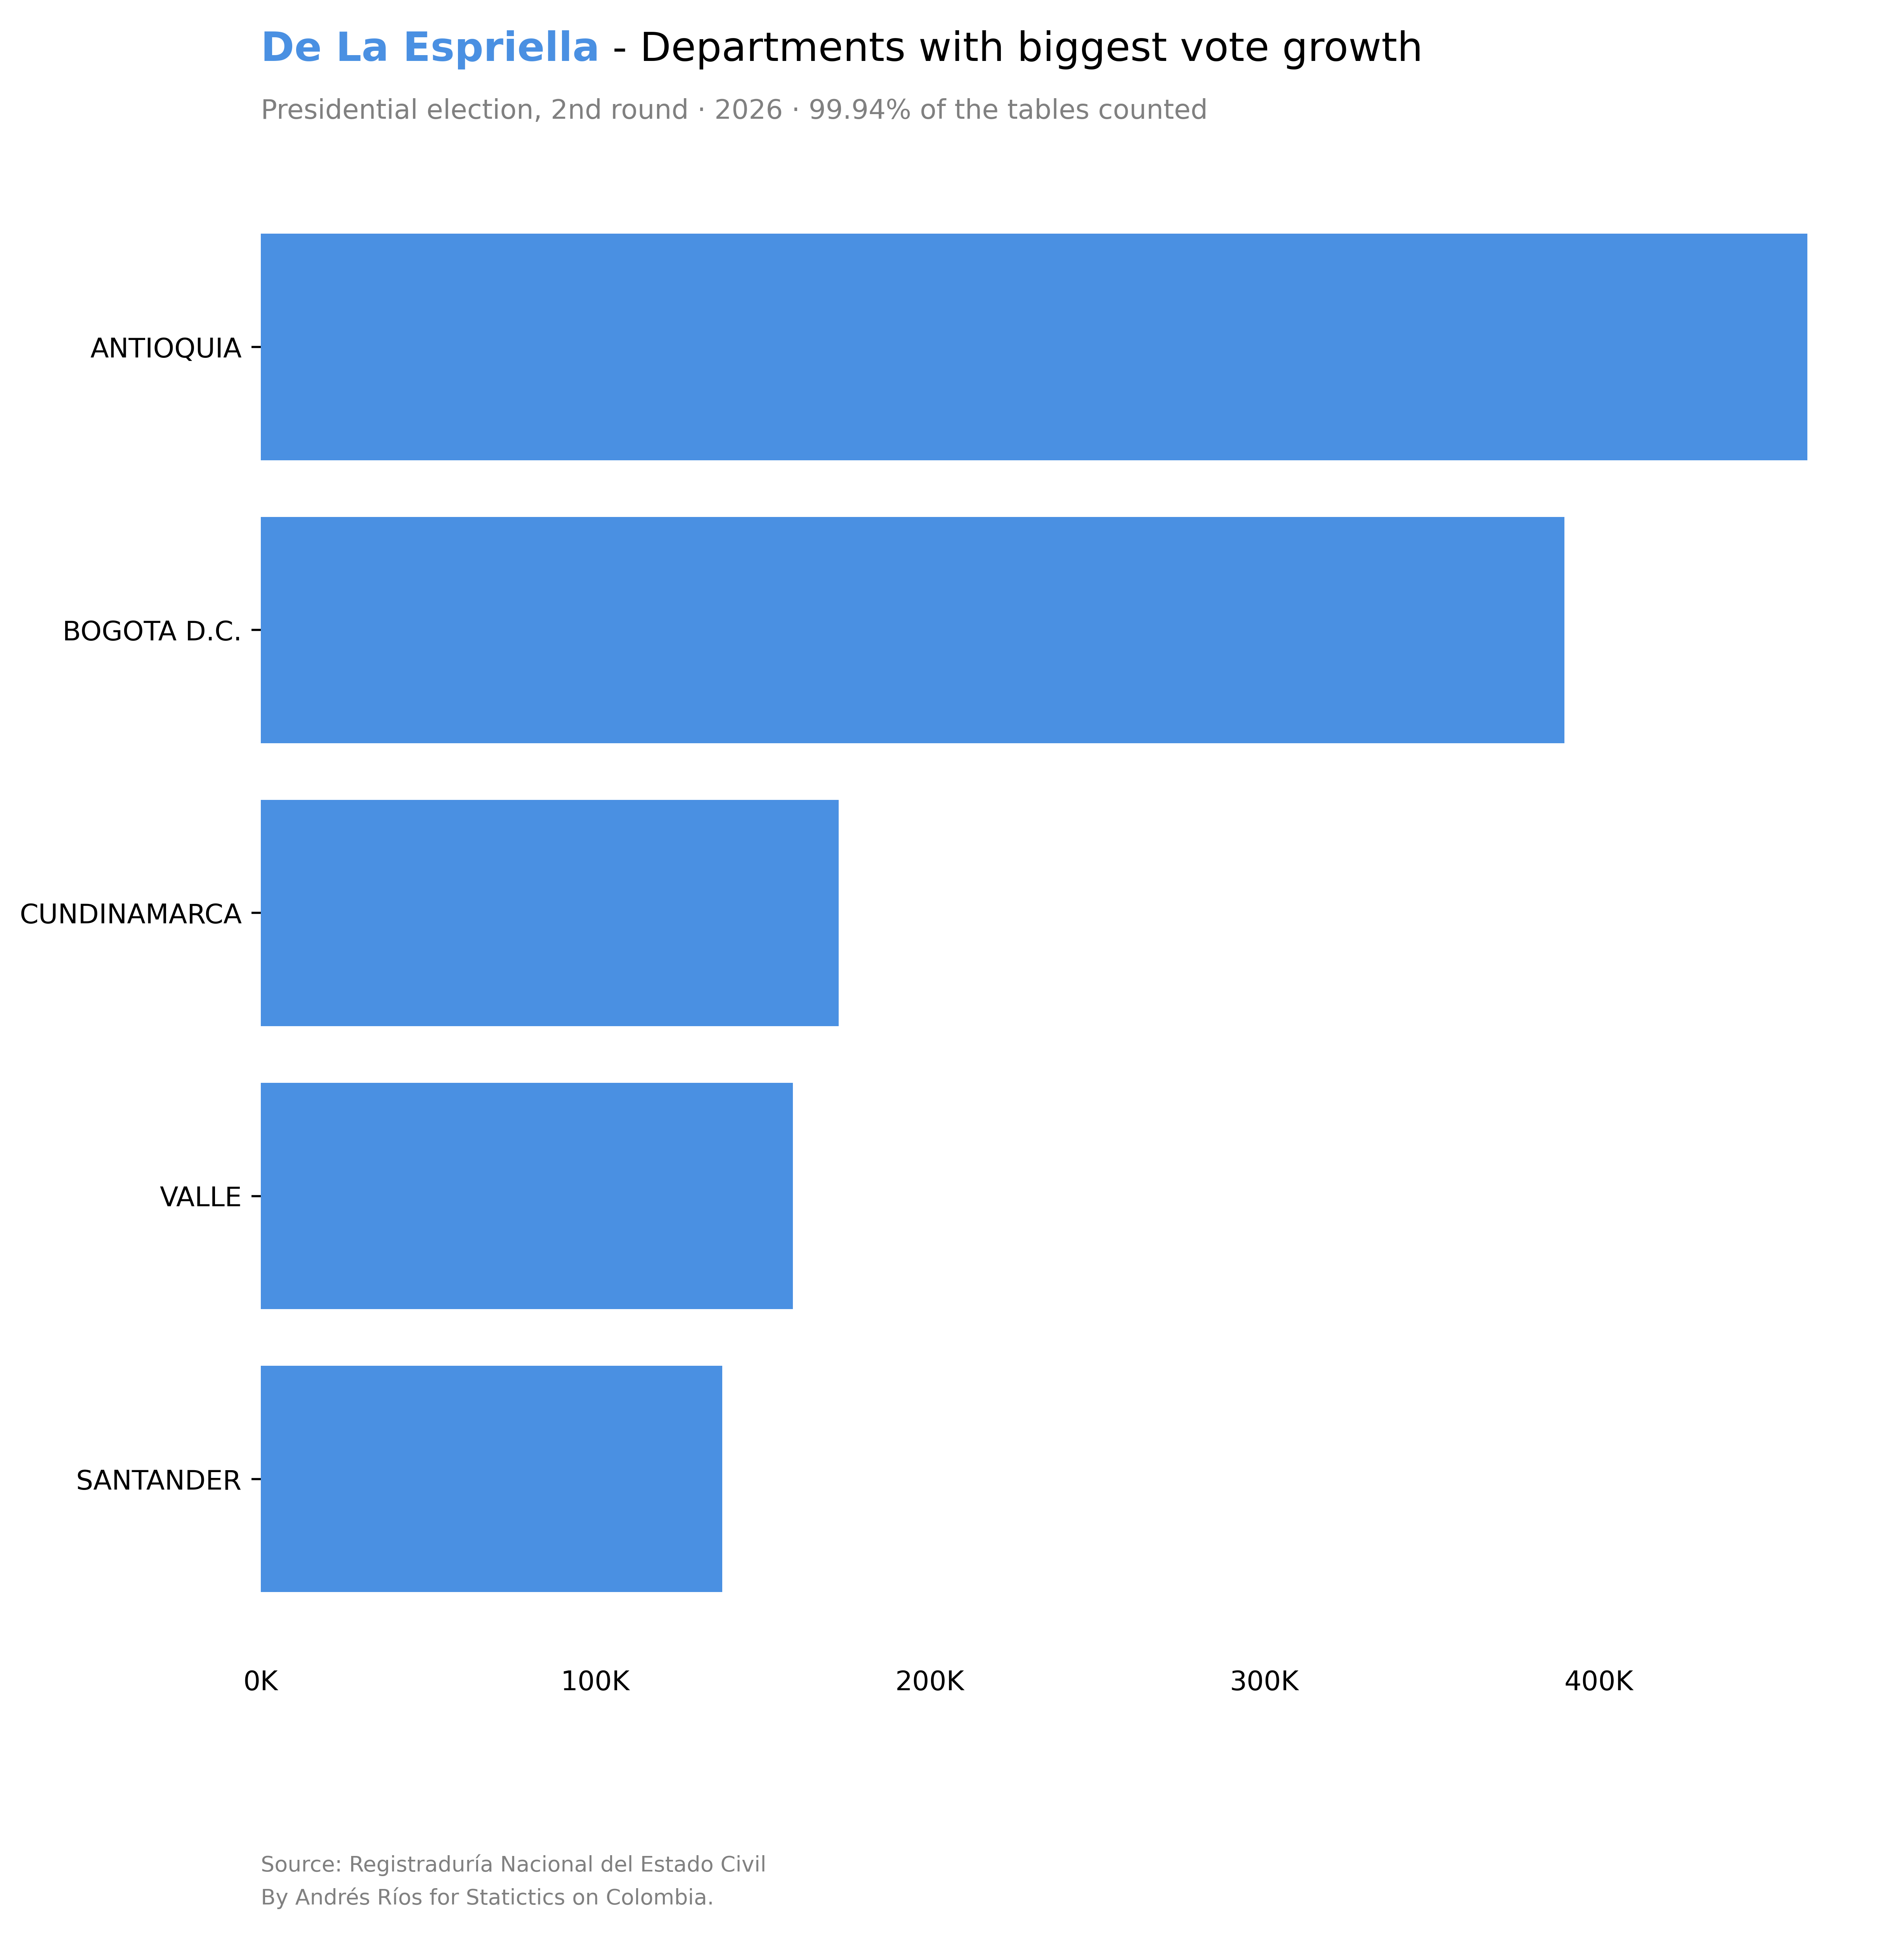

In [6]:
plot_departments(abelardo_growth, "De La Espriella", "#4A90E2", "Departments with biggest vote growth")